In [ ]:
import sys
from pathlib import Path

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

import warnings

In [ ]:
PROJECT_ROOT = Path.cwd().parent

CRIME_PARQUET_PATH = PROJECT_ROOT / "data" / "processed" / "crimes_clean_dedup_all_years.parquet"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"


TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

CRIME_PARQUET_PATH

WindowsPath('c:/Users/Alejandro/Desktop/Uni Files/cbl_crime/cbl_20/data/processed/crimes_clean_dedup_all_years.parquet')

In [3]:
monthly_counts = duckdb.sql(f"""
    SELECT
        "Month" AS month,
        COUNT(*) AS total_crime
    FROM read_parquet('{CRIME_PARQUET_PATH.as_posix()}')
    GROUP BY "Month"
    ORDER BY "Month"
""").df()

monthly_counts["month"] = pd.to_datetime(monthly_counts["month"], format="%Y-%m")
monthly_counts = monthly_counts.sort_values("month").reset_index(drop=True)

monthly_counts.head()

,month,total_crime
0,2010-12-01,284742
1,2011-01-01,309898
2,2011-02-01,309403
3,2011-03-01,337218
4,2011-04-01,347824


In [4]:
monthly_counts.tail()

,month,total_crime
179,2025-11-01,323872
180,2025-12-01,311925
181,2026-01-01,303955
182,2026-02-01,294409
183,2026-03-01,334163


In [5]:
base_period = monthly_counts[
    (monthly_counts["month"] >= "2012-01-01") &
    (monthly_counts["month"] <= "2019-12-01")
].copy()

base_period.head(), base_period.tail()

(        month  total_crime
 13 2012-01-01       355789
 14 2012-02-01       343413
 15 2012-03-01       389629
 16 2012-04-01       352094
 17 2012-05-01       379146,
          month  total_crime
 104 2019-08-01       379699
 105 2019-09-01       364901
 106 2019-10-01       376601
 107 2019-11-01       357754
 108 2019-12-01       341265)

In [ ]:
print("Number of months", len(base_period))
print("Start", base_period["month"].min())
print("End", base_period["month"].max())

Number of months: 96
Start: 2012-01-01 00:00:00
End: 2019-12-01 00:00:00


In [7]:
series = (
    base_period
    .set_index("month")["total_crime"]
    .asfreq("MS")
)

series.head()

month
2012-01-01    355789
2012-02-01    343413
2012-03-01    389629
2012-04-01    352094
2012-05-01    379146
Freq: MS, Name: total_crime, dtype: int64

In [8]:
train = series.loc["2012-01-01":"2018-12-01"]
test = series.loc["2019-01-01":"2019-12-01"]

print("Train", train.index.min(), "to", train.index.max(), "| n =", len(train))
print("Test", test.index.min(), "to", test.index.max(), "| n =", len(test))

Train 2012-01-01 00:00:00 to 2018-12-01 00:00:00 | n = 84
Test 2019-01-01 00:00:00 to 2019-12-01 00:00:00 | n = 12


In [ ]:


def evaluate_forecast(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = mean_squared_error(actual, predicted) ** 0.5
    return mae, rmse


candidate_models = [
    # Simpler models
    ((0, 1, 0), (0, 1, 0, 12)),
    ((0, 1, 0), (0, 1, 1, 12)),
    ((0, 1, 1), (0, 1, 1, 12)),
    ((1, 1, 0), (1, 1, 0, 12)),

    # Moderate models
    ((1, 1, 1), (0, 1, 1, 12)),
    ((0, 1, 1), (1, 1, 0, 12)),
    ((1, 1, 0), (0, 1, 1, 12)),
    ((1, 1, 1), (1, 1, 0, 12)),

    # Your original model
    ((1, 1, 1), (1, 1, 1, 12)),

    # Less differencing options
    ((1, 0, 1), (1, 1, 1, 12)),
    ((1, 0, 0), (1, 1, 0, 12)),
    ((0, 0, 1), (0, 1, 1, 12)),
]

In [ ]:
results = []

for order, seasonal_order in candidate_models:
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            model = SARIMAX(
                train,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            fitted = model.fit(disp=False)
            forecast = fitted.forecast(steps=len(test))
            forecast.index = test.index

            mae, rmse = evaluate_forecast(test, forecast)

            results.append({
                "order": order,
                "seasonal_order": seasonal_order,
                "aic": fitted.aic,
                "bic": fitted.bic,
                "mae": mae,
                "rmse": rmse,
                "status": "success"
            })

    except Exception as e:
        results.append({
            "order": order,
            "seasonal_order": seasonal_order,
            "aic": np.nan,
            "bic": np.nan,
            "mae": np.nan,
            "rmse": np.nan,
            "status": f"failed: {str(e)[:80]}"
        })

sarima_search_results = pd.DataFrame(results).sort_values("mae")
sarima_search_results

In [9]:
seasonal_naive_pred = train.loc["2018-01-01":"2018-12-01"].copy()
seasonal_naive_pred.index = test.index

seasonal_naive_pred.head()

month
2019-01-01    372752
2019-02-01    346592
2019-03-01    380571
2019-04-01    388644
2019-05-01    416593
Freq: MS, Name: total_crime, dtype: int64

In [10]:
sarima_model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit(disp=False)

print(sarima_result.summary())

                                     SARIMAX Results                                      
Dep. Variable:                        total_crime   No. Observations:                   84
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -604.077
Date:                            Thu, 21 May 2026   AIC                           1218.154
Time:                                    15:57:02   BIC                           1228.369
Sample:                                01-01-2012   HQIC                          1222.124
                                     - 12-01-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0301      0.386     -0.078      0.938      -0.787       0.727
ma.L1         -0.4978      0.300   

In [11]:
sarima_forecast = sarima_result.forecast(steps=12)
sarima_forecast.index = test.index

sarima_forecast.head()

month
2019-01-01    370777.759464
2019-02-01    351782.162921
2019-03-01    391715.658771
2019-04-01    394307.954144
2019-05-01    420256.996225
Freq: MS, Name: predicted_mean, dtype: float64

In [12]:
def evaluate_forecast(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = mean_squared_error(actual, predicted) ** 0.5
    
    return mae, rmse

In [13]:
sarima_mae, sarima_rmse = evaluate_forecast(test, sarima_forecast)
naive_mae, naive_rmse = evaluate_forecast(test, seasonal_naive_pred)

metrics_df = pd.DataFrame([
    {
        "model": "SARIMA(1,1,1)(1,1,1,12)",
        "mae": sarima_mae,
        "rmse": sarima_rmse,
    },
    {
        "model": "Seasonal naive",
        "mae": naive_mae,
        "rmse": naive_rmse,
    }
])

metrics_df

,model,mae,rmse
0,"SARIMA(1,1,1)(1,1,1,12)",22837.581979,26660.466251
1,Seasonal naive,20650.416667,22822.914740


In [14]:
forecast_comparison = pd.DataFrame({
    "month": test.index,
    "actual": test.values,
    "sarima_forecast": sarima_forecast.values,
    "seasonal_naive_forecast": seasonal_naive_pred.values,
})

forecast_comparison["sarima_error"] = (
    forecast_comparison["actual"] - forecast_comparison["sarima_forecast"]
)

forecast_comparison["seasonal_naive_error"] = (
    forecast_comparison["actual"] - forecast_comparison["seasonal_naive_forecast"]
)

forecast_comparison

,month,actual,sarima_forecast,seasonal_naive_forecast,sarima_error,seasonal_naive_error
0,2019-01-01,377098,370777.759464,372752,6320.240536,4346
1,2019-02-01,362665,351782.162921,346592,10882.837079,16073
2,2019-03-01,400307,391715.658771,380571,8591.341229,19736
3,2019-04-01,394453,394307.954144,388644,145.045856,5809
4,2019-05-01,405239,420256.996225,416593,-15017.996225,-11354
5,2019-06-01,398897,419173.434661,415802,-20276.434661,-16905
6,2019-07-01,400035,436889.680533,435452,-36854.680533,-35417
7,2019-08-01,379699,415048.096720,407572,-35349.096720,-27873
8,2019-09-01,364901,397092.232148,390342,-32191.232148,-25441
9,2019-10-01,376601,418408.575476,408621,-41807.575476,-32020


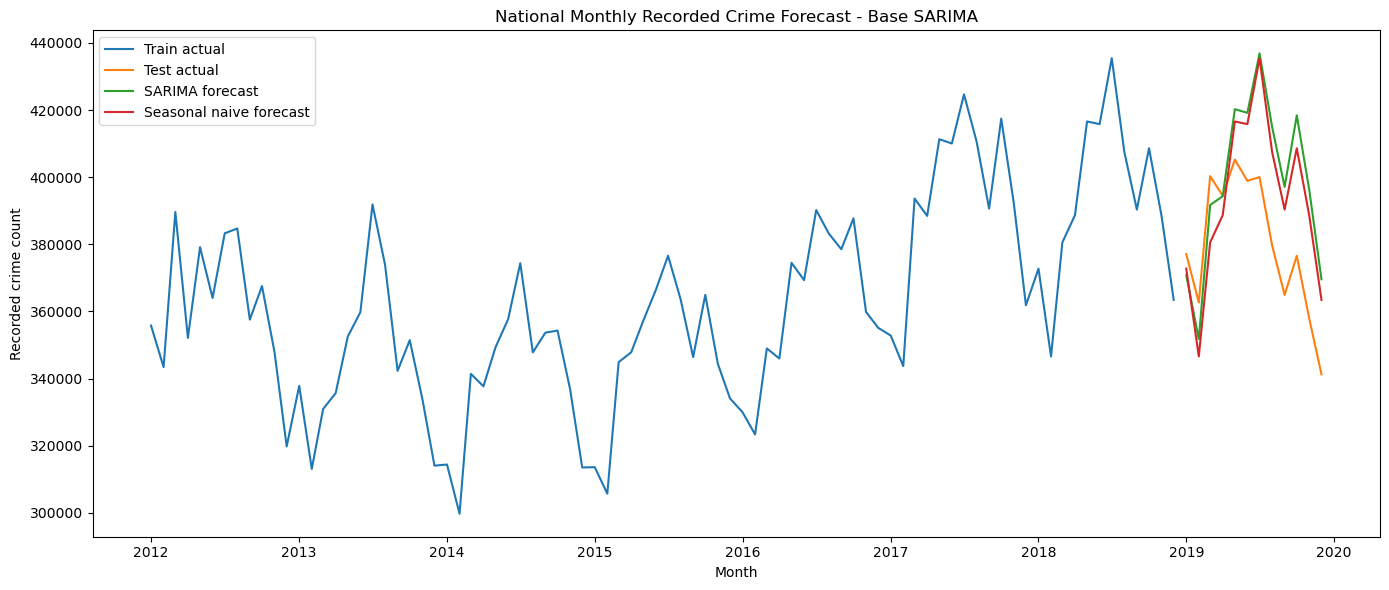

In [15]:
plt.figure(figsize=(14, 6))

plt.plot(train.index, train.values, label="Train actual")
plt.plot(test.index, test.values, label="Test actual")
plt.plot(test.index, sarima_forecast.values, label="SARIMA forecast")
plt.plot(test.index, seasonal_naive_pred.values, label="Seasonal naive forecast")

plt.title("National Monthly Recorded Crime Forecast - Base SARIMA")
plt.xlabel("Month")
plt.ylabel("Recorded crime count")
plt.legend()
plt.tight_layout()
plt.show()

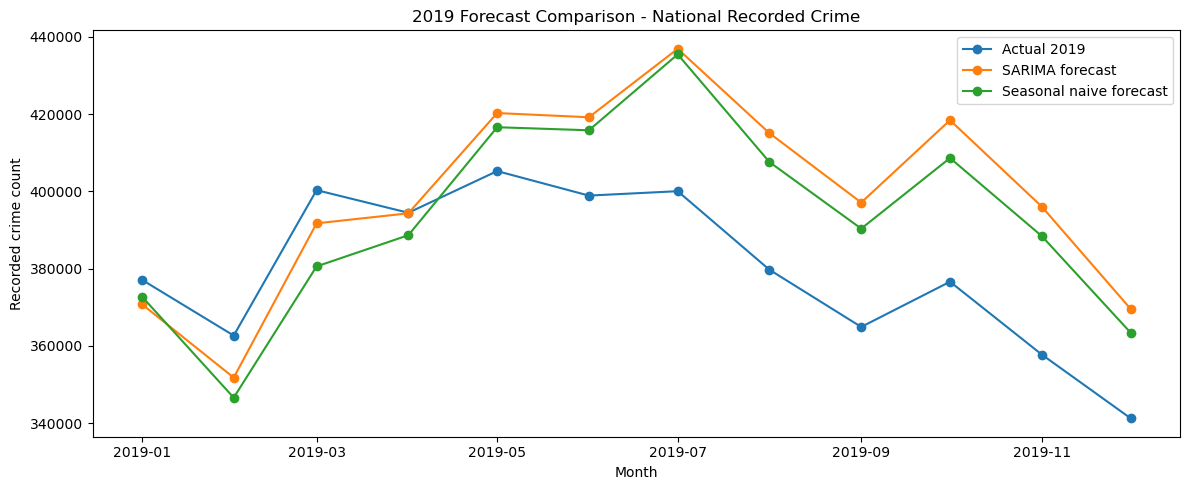

In [16]:
plt.figure(figsize=(12, 5))

plt.plot(test.index, test.values, marker="o", label="Actual 2019")
plt.plot(test.index, sarima_forecast.values, marker="o", label="SARIMA forecast")
plt.plot(test.index, seasonal_naive_pred.values, marker="o", label="Seasonal naive forecast")

plt.title("2019 Forecast Comparison - National Recorded Crime")
plt.xlabel("Month")
plt.ylabel("Recorded crime count")
plt.legend()
plt.tight_layout()
plt.show()